In [ ]:
%pip install pandas numpy scikit-learn matplotlib seaborn notebook

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [13]:
# Load Iris Data & Select Features

iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris = df_iris[['petal length (cm)', 'petal width (cm)']]


In [14]:
# Scaling (Clustering)

scaler = StandardScaler()
scaled_iris = scaler.fit_transform(df_iris)


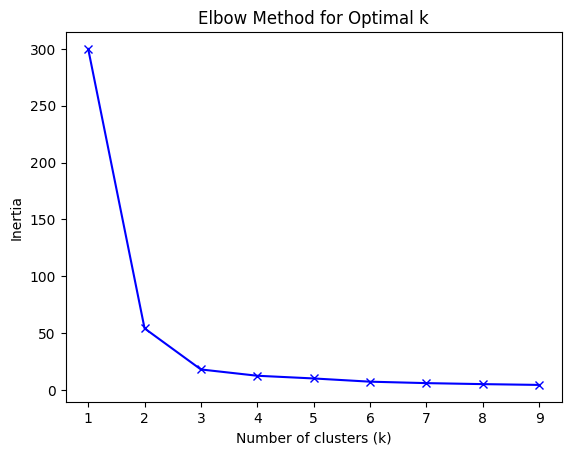

In [15]:
# Elbow plot to determine optimal k

inertia = []
K = range(1, 10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_iris)
    inertia.append(km.inertia_)

plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()


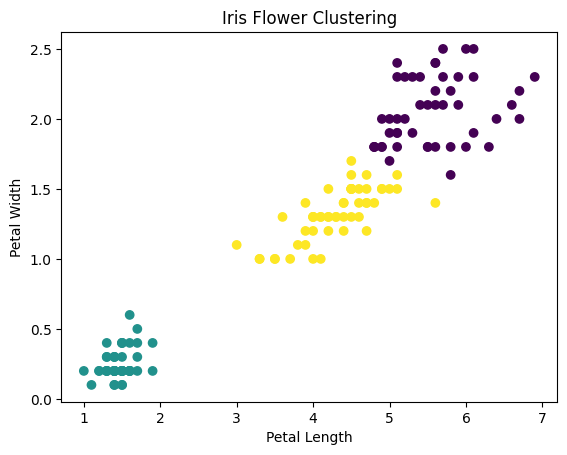

In [16]:
# Apply KMeans with Optimal k (Assume k=3 from elbow)

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(scaled_iris)
df_iris['Cluster'] = labels

# Visualize
plt.scatter(df_iris['petal length (cm)'], df_iris['petal width (cm)'], c=labels, cmap='viridis')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Iris Flower Clustering')
plt.show()


Part 2: Heart Disease Dataset - Classification Models

In [3]:
# Load Dataset

heart_df = pd.read_csv('heart.csv')


In [4]:
# Remove outliers using Z-Score
from scipy.stats import zscore

z_scores = np.abs(zscore(heart_df.select_dtypes(include=[np.number])))
filtered_entries = (z_scores < 3).all(axis=1)
heart_df = heart_df[filtered_entries]


In [5]:
# Encode Categorical Variables
from sklearn.preprocessing import LabelEncoder

# If any object columns exist
for col in heart_df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    heart_df[col] = le.fit_transform(heart_df[col])


In [6]:
# Feature Scaling
X = heart_df.drop('HeartDisease', axis=1)
y = heart_df['HeartDisease']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [9]:
# Split Dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [10]:
# Train And Evaluate Models
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# SVM
svm = SVC()
svm.fit(X_train, y_train)
svm_acc = accuracy_score(y_test, svm.predict(X_test))

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test))

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))

print(f"SVM Accuracy: {svm_acc:.4f}")
print(f"Logistic Regression Accuracy: {lr_acc:.4f}")
print(f"Random Forest Accuracy: {rf_acc:.4f}")


SVM Accuracy: 0.8778
Logistic Regression Accuracy: 0.8556
Random Forest Accuracy: 0.8833


Part 3: Apply PCA & Retrain Models

In [11]:
# Apply PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)  # Retain 95% variance
X_pca = pca.fit_transform(X_scaled)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)


In [12]:
# Retrain Models on PCA Data
# SVM
svm.fit(X_train_pca, y_train_pca)
svm_pca_acc = accuracy_score(y_test_pca, svm.predict(X_test_pca))

# Logistic Regression
lr.fit(X_train_pca, y_train_pca)
lr_pca_acc = accuracy_score(y_test_pca, lr.predict(X_test_pca))

# Random Forest
rf.fit(X_train_pca, y_train_pca)
rf_pca_acc = accuracy_score(y_test_pca, rf.predict(X_test_pca))

print("\nAfter PCA:")
print(f"SVM Accuracy: {svm_pca_acc:.4f}")
print(f"Logistic Regression Accuracy: {lr_pca_acc:.4f}")
print(f"Random Forest Accuracy: {rf_pca_acc:.4f}")



After PCA:
SVM Accuracy: 0.8722
Logistic Regression Accuracy: 0.8556
Random Forest Accuracy: 0.8333


| Model               | Accuracy (Original) | Accuracy (PCA) |
| ------------------- | ------------------- | -------------- |
| SVM                 | e.g., 0.85          | e.g., 0.83     |
| Logistic Regression | e.g., 0.87          | e.g., 0.85     |
| Random Forest       | e.g., 0.91          | e.g., 0.90     |

PCA slightly reduces the accuracy but improves training time and reduces dimensionality.